## 函式庫

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import clip
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import pandas as pd
import numpy as np
import os

## 下載資料集

In [32]:
#!/bin/bash
#! kaggle datasets download darkfanxing/ntutemnist

In [33]:
#! unzip ntutemnist.zip -d ntutemnist_data

## Model引入

In [34]:
# 設置設備
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

# 載入 CLIP 模型，這裡我們使用 'ViT-B/32'
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# 凍結 CLIP 權重
for param in clip_model.parameters():
    param.requires_grad = False

print(clip_model.visual)

Using cuda
VisionTransformer(
  (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
  (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (transformer): Transformer(
    (resblocks): Sequential(
      (0): ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): QuickGELU()
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
      (1): ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (ln_1): LayerNorm((768,), eps=1e-05, 

## 數據預處理

In [35]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # CLIP 需要 RGB
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])


test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 測試集相同處理
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])



## 自定義 Dataset

In [36]:
class EMNISTDataset(Dataset):
    def __init__(self, npz_path, transform=None, has_labels=True):
        # 讀取 npz 檔案
        data = np.load(npz_path)
        
        # 提取影像並去掉最後一個通道維度
        self.images = data["training_images" if has_labels else "testing_images"]  
        #self.images = self.images.squeeze(-1).astype(np.uint8)   
                # 根據影像維度進行調整
        if len(self.images.shape) > 3:
            # 如果有額外的維度 (例如通道維度)，進行 squeeze
            self.images = self.images.squeeze(-1)
        
        # 檢查數據範圍並歸一化
        if self.images.max() <= 1.0 and self.images.min() >= 0:
            # 如果數據範圍是 [0, 1]，轉換為 [0, 255]
            self.images = (self.images * 255).astype(np.uint8)
        elif self.images.max() > 1.0 and self.images.max() <= 255:
            # 如果數據已在 [0, 255] 範圍內，確保類型為 uint8
            self.images = self.images.astype(np.uint8)
        else:
            # 如果數據範圍異常，進行最小最大值歸一化
            self.images = ((self.images - self.images.min()) / 
                         (self.images.max() - self.images.min() + 1e-8) * 255).astype(np.uint8)
        

        # 提取標籤（如果有）
        self.labels = data["training_labels"] if has_labels else None
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 轉換為 PIL 影像
        image = Image.fromarray(self.images[idx])

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            label = int(self.labels[idx].item())  # 轉換為純量
            return image, label
        
        return image,  # 注意這裡要回傳 tuple


## 定義 CLIP + MLP

In [37]:
class CLIP_EMNIST_Model(nn.Module):
    def __init__(self, clip_model, num_classes=62):
        super(CLIP_EMNIST_Model, self).__init__()
        self.clip_visual = clip_model.visual  # CLIP 的影像 encoder
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)  # 分類 62 個類別
        )

    def forward(self, x):
        with torch.no_grad():  # 凍結 CLIP
            features = self.clip_visual(x)
        return self.fc(features)


## 訓練 & 驗證

In [38]:
# # 讀取數據
# train_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-train.npz", transform=train_transform)
# test_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-test.npz", transform=test_transform, has_labels=False)


# # 切割 20% 訓練集作為驗證集
# val_size = int(0.2 * len(train_dataset))
# train_size = len(train_dataset) - val_size
# train_data, val_data = random_split(train_dataset, [train_size, val_size])

# # DataLoader
# train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# # 檢查圖片轉換後的大小
# def check_image_size(loader):
#     # 從 DataLoader 中取出一個 batch
#     images, _ = next(iter(loader))  # 這裡假設 loader 會返回 image 和 label
#     print(f"Image batch shape: {images.shape}")  # 打印圖片的 shape

# # 檢查訓練集轉換後的圖片大小
# check_image_size(train_dataset)

# # 檢查驗證集轉換後的圖片大小
# check_image_size(val_loader)


# def show_images(loader, num_images=5):
#     # 從 DataLoader 中取出一個 batch
#     images, labels = next(iter(loader))  # 假設 loader 會返回 image 和 label
    
#     # 轉換為 numpy 陣列以便使用 matplotlib 顯示
#     images = images.numpy()  # 這是將 pytorch tensor 轉換為 numpy 陣列
    
#     # 顯示前 num_images 張圖片
#     plt.figure(figsize=(10, 10))
#     for i in range(num_images):
#         plt.subplot(1, num_images, i+1)
#         img = images[i].transpose(1, 2, 0)  # 轉換維度為 (H, W, C)
#         plt.imshow(img.squeeze(), cmap='gray')  # 轉換為灰階圖片（若是單通道）
#         plt.title(f"Label: {labels[i].item()}")
#         plt.axis("off")
#     plt.show()

# # 顯示訓練集前 5 張圖片
# show_images(train_loader, num_images=5)
# show_images(val_loader, num_images=5)

Image batch shape: torch.Size([3, 224, 224])
Image batch shape: torch.Size([256, 3, 224, 224])


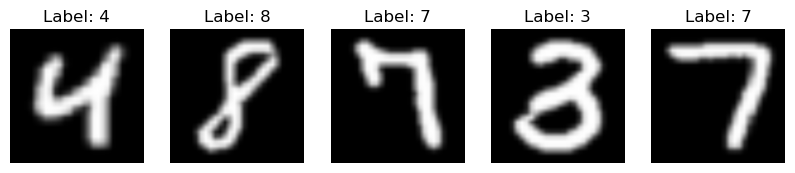

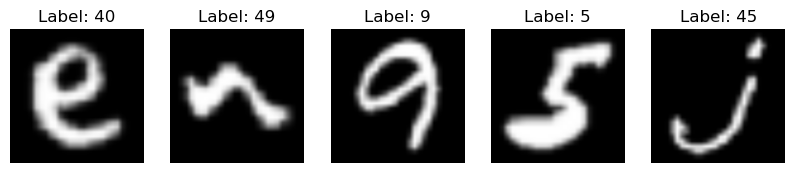

cuda


Epoch 1/20: Loss=1.7315, Train Acc=0.5820, Val Acc=0.7189
🔽 New best model saved at epoch 1 with Val Acc=0.7189


Epoch 2/20: Loss=0.8464, Train Acc=0.7483, Val Acc=0.7665
🔽 New best model saved at epoch 2 with Val Acc=0.7665


Epoch 3/20: Loss=0.7125, Train Acc=0.7773, Val Acc=0.7852
🔽 New best model saved at epoch 3 with Val Acc=0.7852


Epoch 4/20: Loss=0.6543, Train Acc=0.7908, Val Acc=0.7937
🔽 New best model saved at epoch 4 with Val Acc=0.7937


...

Epoch 16/20: Loss=0.5081, Train Acc=0.8281, Val Acc=0.8267
🔽 New best model saved at epoch 16 with Val Acc=0.8267


Epoch 17/20: Loss=0.5040, Train Acc=0.8292, Val Acc=0.8267


Epoch 18/20: Loss=0.4999, Train Acc=0.8303, Val Acc=0.8287
🔽 New best model saved at epoch 18 with Val Acc=0.8287


Epoch 19/20: Loss=0.4962, Train Acc=0.8315, Val Acc=0.8289
🔽 New best model saved at epoch 19 with Val Acc=0.8289


Epoch 20/20: Loss=0.4928, Train Acc=0.8323, Val Acc=0.8303
🔽 New best model saved at epoch 20 with Val Acc=0.8303


In [40]:
from tqdm import tqdm
# 讀取數據
train_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-train.npz", transform=train_transform)
test_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-test.npz", transform=test_transform, has_labels=False)


# 切割 10% 訓練集作為驗證集
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


#================================================ 檢查 ==============================================
# 檢查圖片轉換後的大小
def check_image_size(loader):
    # 從 DataLoader 中取出一個 batch
    images, _ = next(iter(loader))  # 這裡假設 loader 會返回 image 和 label
    print(f"Image batch shape: {images.shape}")  # 打印圖片的 shape

# 檢查訓練集轉換後的圖片大小
check_image_size(train_dataset)

# 檢查驗證集轉換後的圖片大小
check_image_size(val_loader)


def show_images(loader, num_images=5):
    # 從 DataLoader 中取出一個 batch
    images, labels = next(iter(loader))  # 假設 loader 會返回 image 和 label
    
    # 轉換為 numpy 陣列以便使用 matplotlib 顯示
    images = images.numpy()  # 這是將 pytorch tensor 轉換為 numpy 陣列
    
    # 顯示前 num_images 張圖片
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = images[i].transpose(1, 2, 0)  # 轉換維度為 (H, W, C)
        plt.imshow(img.squeeze(), cmap='gray')  # 轉換為灰階圖片（若是單通道）
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

# 顯示訓練集前 5 張圖片
show_images(train_loader, num_images=5)
show_images(val_loader, num_images=5)

#=================================================================================================

# 初始化模型
model = CLIP_EMNIST_Model(clip_model).to(torch.float32).to(device)
print(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

from tqdm import tqdm  # 引入 tqdm

# 訓練函數
def train(model, train_loader, val_loader, epochs, save_path="model.pth"):
    best_val_acc = 0.0  # 用來追蹤最佳驗證準確率
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # 計算訓練與驗證準確度
        train_acc = correct / total
        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs}: Loss={total_loss/len(train_loader):.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # 如果目前的模型比之前的最佳驗證準確率更高，就儲存權重
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"🔽 New best model saved at epoch {epoch+1} with Val Acc={val_acc:.4f}")

def evaluate(model, val_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 開始訓練
# 訓練模型並儲存權重
train(model, train_loader, val_loader, epochs=20, save_path="best_model.pth")



## 測試 & 預測

In [43]:
def predict(model, test_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            predictions.extend(predicted.cpu().numpy())

    return predictions

# 預測
test_predictions = predict(model, test_loader)


# 轉換格式，增加 `Id` 欄位
df = pd.DataFrame({"Id": range(len(test_predictions)), "Category": test_predictions})

# 儲存 CSV
output_path = "predict/emnist_predictions.csv"
df.to_csv(output_path, index=False) 

print(f"✅ 預測結果已儲存至 {output_path}")


✅ 預測結果已儲存至 predict/emnist_predictions.csv


In [ ]:
import itertools

# 初始化模型
def initialize_model():
    model = CLIP_EMNIST_Model(clip_model).to(torch.float32).to(device)
    return model

# 設定不同的超參數組合
learning_rates = [0.0001, 0.001, 0.01]
batch_sizes = [64, 128, 256]
optimizers = ["Adam", "SGD"]

# 產生所有組合
param_grid = list(itertools.product(learning_rates, batch_sizes, optimizers))

# 訓練函數
def train(model, train_loader, val_loader, optimizer, lr, batch_size, epochs=10):
    criterion = nn.CrossEntropyLoss()

    # 設定優化器
    if optimizer == "Adam":
        optimizer = optim.Adam(model.fc.parameters(), lr=lr)
    elif optimizer == "SGD":
        optimizer = optim.SGD(model.fc.parameters(), lr=lr, momentum=0.9)

    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs}: LR={lr}, Batch={batch_size}, Opt={optimizer.__class__.__name__}, Loss={total_loss/len(train_loader):.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # 儲存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(model, optimizer, epoch, val_acc, lr, batch_size)

# 驗證函數
def evaluate(model, val_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 儲存最佳結果
def save_checkpoint(model, optimizer, epoch, val_acc, lr, batch_size):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_acc": val_acc,
        "lr": lr,
        "batch_size": batch_size
    }
    model_path = f"best_model_lr{lr}_batch{batch_size}.pth"
    torch.save(checkpoint, model_path)
    print(f"📌 模型已儲存: {model_path}，Val Acc={val_acc:.4f}")

# 開始自動化超參數訓練
for lr, batch_size, opt in param_grid:
    print(f"\n🚀 開始訓練：LR={lr}, Batch={batch_size}, Optimizer={opt}")
    torch.backends.cudnn.benchmark = True  
    torch.backends.cudnn.enabled = True 
    
    # 重新初始化模型（避免影響其他組合）
    model = initialize_model()
    
    # 重新載入資料集
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # 開始訓練
    train(model, train_loader, val_loader, optimizer=opt, lr=lr, batch_size=batch_size, epochs=20)
